In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time as time
#np.random.seed(845709)

In [3]:
uniforme = np.random.uniform(0,1)

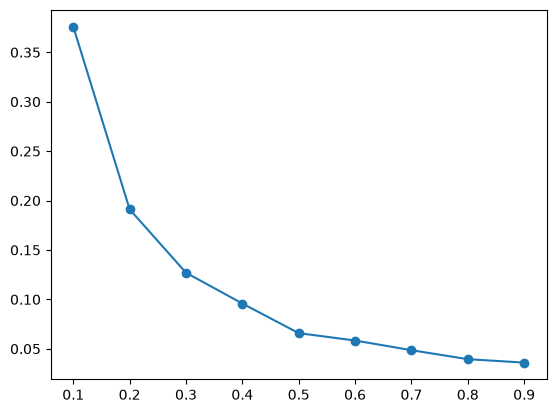

In [4]:
def gerar_geometrica(p, m):
    amostra = []
    for j in range(m):
        i = 1
        while p < np.random.uniform(0, 1):
            i += 1
        amostra.append(i)
    return amostra

m = 10000
probabilidades = np.linspace(0.1, 0.9, 9) 
tempos = []

for p in probabilidades:
    inicio = time.time()
   
    amostra_final = gerar_geometrica(p, m)
    
    final = time.time()
    tempo = final - inicio
    
    tempos.append(tempo)
plt.plot(probabilidades, tempos, marker='o')
plt.show()

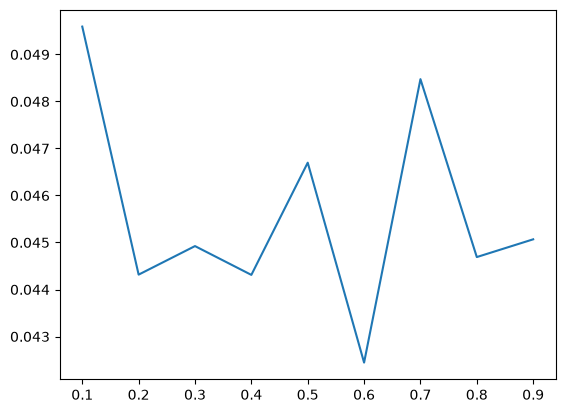

In [5]:
#Criei uma função para criar as geométricas.
def gerar_geometrica_inversa(p, m):
    amostra = []
    
    for j in range(m):
        u = np.random.uniform(0, 1)
        i = np.ceil(np.log(1 - u) / np.log(1 - p))
        amostra.append(i)
        
    return amostra

m = 10000
probabilidades = np.linspace(0.1, 0.9, 9) 
tempos2 = []
#Aqui calculo o tempo para cada prob usando o linspace, assim consigo ver a diferença de tempo para cada probabildiade.
for p in probabilidades:
    inicio = time.time()
    

    amostra_final2 = gerar_geometrica_inversa(p, m)
    
    final = time.time()
    tempo = final - inicio
    tempos2.append(tempo)
plt.plot(probabilidades, tempos2)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

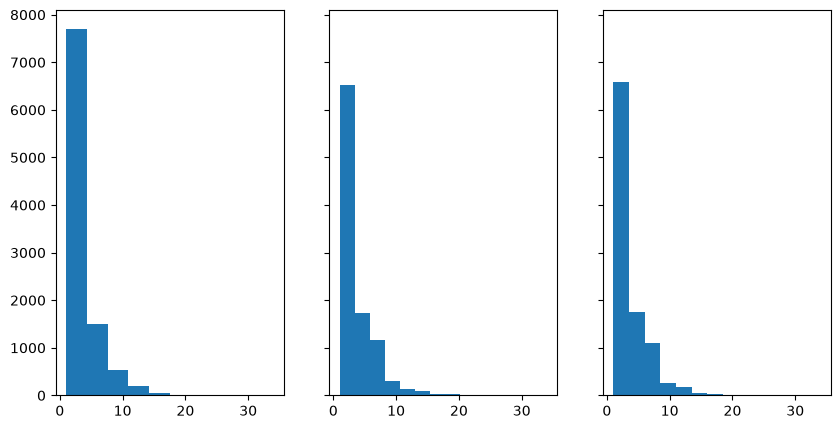

In [6]:
p = 0.3
amostra_final3 = np.random.geometric(0.3,size=10000)
fig ,ax = plt.subplots(1,3,figsize=(10,5),sharex=True,sharey=True)
ax[0].hist(gerar_geometrica(0.3,10000))
ax[1].hist(gerar_geometrica_inversa(0.3,10000))
ax[2].hist(amostra_final3)
plt.show

Podemos ver que as médias são bem próximas de 3, como deveria ser, pois E(x) = 1/p, e meu p é 0.3

In [7]:
amostra_final2 = gerar_geometrica_inversa(0.3,10000)
np.mean(amostra_final2)


np.float64(3.3259)

In [8]:
amostra_final = gerar_geometrica(0.3,10000)
np.mean(amostra_final)

np.float64(3.3187)

In [9]:
np.mean(amostra_final3)

np.float64(3.3167)

In [10]:
#Aqui com a poisson foi bem simples, apenas apliquei o método recursivo.
poissons = []
for j in range(m):
    uniforme = np.random.uniform(0,1)
    lam = 3
    i = 0
    p = np.exp(-lam)
    F = p
    while uniforme>F:
        i +=1
        p = p*(lam/i)
        F+=p
    poissons.append(i)
#print(poissons)
print(np.mean(poissons), np.mean(np.random.poisson(lam=3,size=10000)))
#Médias bem próximas de 3 como deveria ser, pois a média da poisson para lambda = 3 é 3.



2.9878 3.0218


<function matplotlib.pyplot.show(close=None, block=None)>

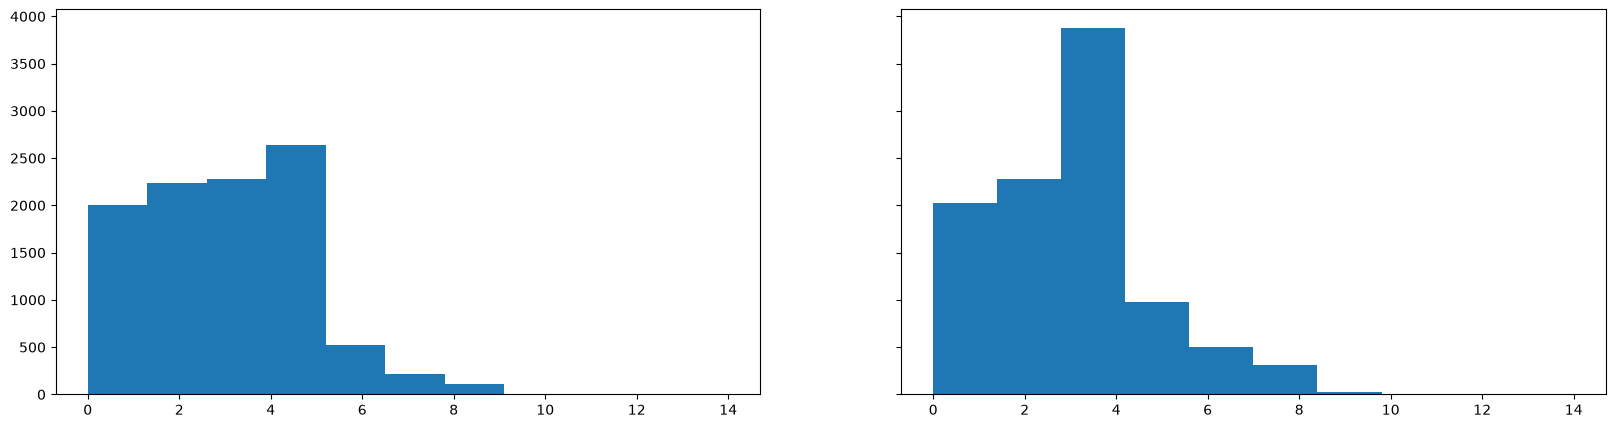

In [12]:
fig ,ax = plt.subplots(1,2,figsize=(20,5),sharex=True,sharey=True)
ax[0].hist(poissons)
ax[1].hist(np.random.poisson(lam=3,size=10000))
plt.show